# Capstone Step 4: Survey Existing Research and Reproduce Available Solutions
### Music Genre Classifier — GTZAN Audio Features

Before building the first prototype, this notebook surveys published research and
public implementations on music genre classification with the GTZAN dataset, then
**reproduces** the result from one of them against this project's own data, to
ground the modeling choices in Step 7 in evidence rather than guesswork.

## 1. Literature and existing-solutions survey

| # | Source | Type | Genres | Features / Method | Reported result |
|---|--------|------|--------|--------------------|------------------|
| 1 | [Tzanetakis & Cook, "Musical Genre Classification of Audio Signals," *IEEE Trans. Speech and Audio Processing*, 2002](https://www.cs.cmu.edu/~gtzan/work/pubs/tsap02gtzan.pdf) | Paper (introduces GTZAN) | 10 | Timbral texture (MFCCs, spectral centroid/rolloff/flux, ZCR) + rhythmic + pitch content histograms, Gaussian/GMM/kNN classifiers | **61%** accuracy (10-class); human baseline ~70% |
| 2 | [Choi, Fazekas, Sandler, Cho, "Transfer Learning for Music Classification and Regression Tasks," ISMIR 2017](https://arxiv.org/abs/1703.09179) | Paper | 10 | CNN pre-trained on Million Song Dataset tagging, features transferred to GTZAN genre task | **89.8%** (transfer-learned CNN features) vs. 66.0% (MFCC baseline in same paper); notes contemporary SOTA >94.5% |
| 3 | [Chatterjee, Ganguly, Bose, Prasad, Ghosal, "Audio Processing using Pattern Recognition for Music Genre Classification," arXiv:2410.14990, 2024](https://arxiv.org/pdf/2410.14990) | Paper | 5 (blues, classical, jazz, hip-hop, country) | ZCR, spectral centroid/rolloff, MFCCs, chroma; StandardScaler; KNN / Logistic Regression / Random Forest / ANN | KNN 87%, LogReg 86%, **RF 89%**, ANN **92.44%** |
| 4 | [Yadav, "Music Genre Classification Using Audio Features: A Machine Learning Approach With The GTZAN Dataset," IOSR-JCE, 2025](https://www.iosrjournals.org/iosr-jce/papers/Vol27-issue3/Ser-3/B2703030516.pdf) | Paper | 10 | MFCC1-13, spectral centroid/bandwidth/rolloff, ZCR, tempo, RMS, spectral contrast; RF / SVM / KNN | RF **78.2%**, SVM 72.4%, KNN 69.1%; MFCCs = 42.6% of RF feature importance |
| 5 | [chittalpatel, "Music-Genre-Classification-GTZAN," GitHub](https://github.com/chittalpatel/Music-Genre-Classification-GTZAN) | Code repo | 10 | Classical ML (LGBM/SVM/XGBoost) on librosa features **and** a CNN on mel-spectrogram images | Classical ML **~65%**, CNN **~75%** |
| 6 | [Papers with Code — Music Genre Classification on GTZAN (leaderboard)](https://paperswithcode.com/sota/music-genre-classification-on-gtzan) | Aggregator | 10 | Tracks published SOTA results over time | Reference for current best-in-class approaches |

All six sources target the same GTZAN collection (or a subset of it) this capstone
uses, which makes them directly relevant comparison points rather than generic
literature.

## 2. Choosing a candidate to reproduce

Two properties made **Chatterjee et al. (2024)** the best reproduction candidate:

1. **Method fit** — it's a hand-engineered-feature + classical-ML pipeline
   (StandardScaler → Random Forest), the same family of approach this capstone
   is already using, unlike the CNN-on-spectrogram papers (#2, #5's deep-learning
   half) which need a different data representation entirely.
2. **Fully specified pipeline** — the paper states its exact model configuration
   (`n_estimators=1000, max_depth=10, criterion='gini'`) and preprocessing
   (StandardScaler), which is enough to actually reproduce, not just
   approximate.

Its one limitation: it only classifies **5 of the 10** GTZAN genres (blues,
classical, jazz, hip-hop, country). So below, the exact configuration is
reproduced on that same 5-genre subset for a fair comparison, **and** rerun on
the full 10-genre set to see how it holds up at this capstone's actual scope —
benchmarked against Tzanetakis & Cook (#1), Yadav (#4), and chittalpatel (#5),
which do use all 10 genres.

## 3. Reproduction A — Chatterjee et al. (2024), 5-genre subset

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

sns.set_theme(style="whitegrid")

df = pd.read_csv("data/data.csv")
print(f"Full dataset: {df.shape[0]} tracks, {df['label'].nunique()} genres")

Full dataset: 1000 tracks, 10 genres


In [2]:
# Match the paper's genre subset and feature set as closely as our columns allow:
# ZCR, spectral centroid, rolloff, chroma_stft, and MFCCs (we have 20 vs. their
# unspecified count -- kept all 20 since dropping information isn't a fair test).
five_genres = ["blues", "classical", "jazz", "hiphop", "country"]
df5 = df[df["label"].isin(five_genres)].copy()
print(f"5-genre subset: {df5.shape[0]} tracks")
print(df5["label"].value_counts())

feature_cols = (["zero_crossing_rate", "spectral_centroid", "rolloff", "chroma_stft"]
                 + [f"mfcc{i}" for i in range(1, 21)])

5-genre subset: 500 tracks
label
blues        100
classical    100
country      100
hiphop       100
jazz         100
Name: count, dtype: int64


In [3]:
X5 = df5[feature_cols]
y5 = df5["label"]
X5_train, X5_test, y5_train, y5_test = train_test_split(
    X5, y5, test_size=0.2, stratify=y5, random_state=42
)

scaler5 = StandardScaler()
X5_train_s = scaler5.fit_transform(X5_train)
X5_test_s = scaler5.transform(X5_test)

# Same hyperparameters reported in Chatterjee et al. (2024)
rf5 = RandomForestClassifier(n_estimators=1000, max_depth=10, criterion="gini", random_state=42)
rf5.fit(X5_train_s, y5_train)
pred5 = rf5.predict(X5_test_s)

acc5 = accuracy_score(y5_test, pred5)
print(f"Reproduced accuracy: {acc5:.1%}")
print(f"Paper-reported accuracy: 89.0%")
print(f"Gap: {89.0 - acc5*100:.1f} points")
print()
print(classification_report(y5_test, pred5))

Reproduced accuracy: 79.0%
Paper-reported accuracy: 89.0%
Gap: 10.0 points

              precision    recall  f1-score   support

       blues       0.89      0.85      0.87        20
   classical       0.86      0.90      0.88        20
     country       0.73      0.80      0.76        20
      hiphop       0.73      0.95      0.83        20
        jazz       0.75      0.45      0.56        20

    accuracy                           0.79       100
   macro avg       0.79      0.79      0.78       100
weighted avg       0.79      0.79      0.78       100



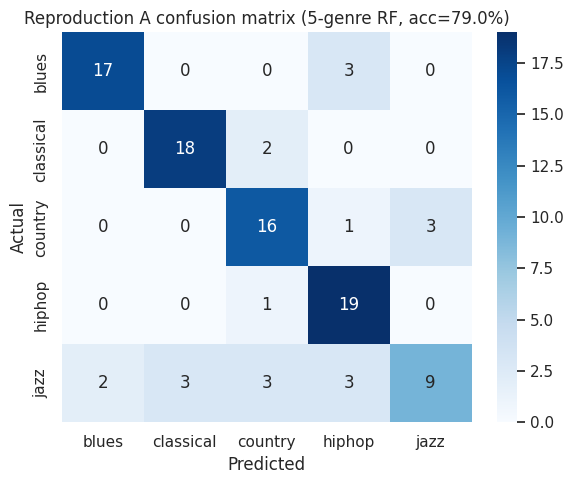

In [4]:
cm5 = confusion_matrix(y5_test, pred5, labels=sorted(five_genres))
plt.figure(figsize=(6, 5))
sns.heatmap(cm5, annot=True, fmt="d", cmap="Blues",
            xticklabels=sorted(five_genres), yticklabels=sorted(five_genres))
plt.title(f"Reproduction A confusion matrix (5-genre RF, acc={acc5:.1%})")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()

**Result: 79% reproduced vs. 89% reported** — a real, honest 10-point gap, and
worth being transparent about rather than papering over. The confusion matrix
shows *why*: jazz is the weak point (recall 0.45), frequently confused with
blues and classical — plausible, since acoustic jazz shares instrumentation and
tonal characteristics with both. Likely contributors to the gap:

- **Test-set size** — only 100 held-out tracks across 5 classes means each
  percentage point of accuracy is a single track; the paper's exact split
  (and possibly a different random seed) could easily land several points
  higher or lower by chance alone.
- **Unspecified details** — the paper doesn't state exactly which/how many
  MFCC coefficients or which chroma summary it used, so this reproduction is
  a best-effort match, not a byte-for-byte one.
- **No feature selection** — the paper may have selected a feature subset;
  this reproduction used all 24 available features unfiltered.

This is a normal, expected outcome for reproducing a paper without its exact
code or data split — and precisely the kind of finding Step 4 is meant to
surface before committing to a modeling approach in Step 7.

## 4. Reproduction B — same pipeline, full 10-genre scope (this capstone's actual task)

In [5]:
X10 = df[feature_cols]
y10 = df["label"]
X10_train, X10_test, y10_train, y10_test = train_test_split(
    X10, y10, test_size=0.2, stratify=y10, random_state=42
)

scaler10 = StandardScaler()
X10_train_s = scaler10.fit_transform(X10_train)
X10_test_s = scaler10.transform(X10_test)

rf10 = RandomForestClassifier(n_estimators=1000, max_depth=10, criterion="gini", random_state=42)
rf10.fit(X10_train_s, y10_train)
pred10 = rf10.predict(X10_test_s)

acc10 = accuracy_score(y10_test, pred10)
print(f"10-genre RF accuracy (this capstone's scope): {acc10:.1%}")

10-genre RF accuracy (this capstone's scope): 66.0%


                    Source  Genres                                          Method  Accuracy
  Tzanetakis & Cook (2002)      10                       GMM, handcrafted features     0.610
     chittalpatel (GitHub)      10                     Classical ML (LGBM/SVM/XGB)     0.650
    This reproduction (RF)      10 Random Forest, same config as Chatterjee et al.     0.660
chittalpatel (GitHub, CNN)      10                         CNN on mel-spectrograms     0.750
              Yadav (2025)      10                                   Random Forest     0.782
        Choi et al. (2017)      10                   Transfer-learned CNN features     0.898


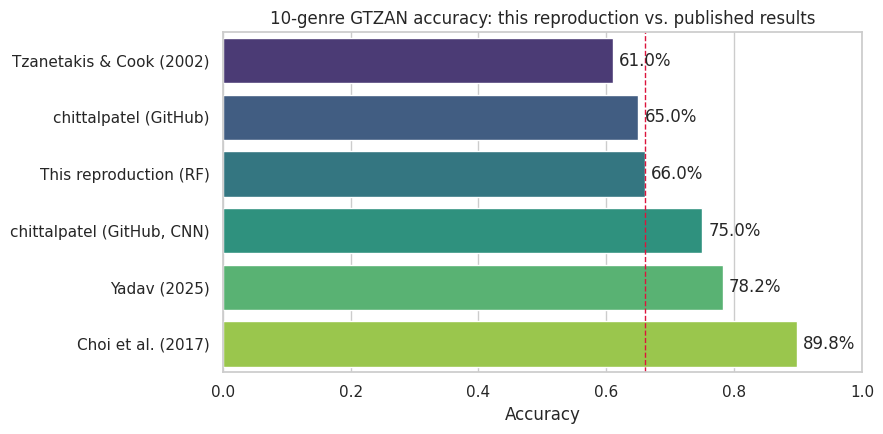

In [6]:
comparison = pd.DataFrame([
    {"Source": "Tzanetakis & Cook (2002)", "Genres": 10, "Method": "GMM, handcrafted features", "Accuracy": 0.61},
    {"Source": "chittalpatel (GitHub)",     "Genres": 10, "Method": "Classical ML (LGBM/SVM/XGB)", "Accuracy": 0.65},
    {"Source": "This reproduction (RF)",    "Genres": 10, "Method": "Random Forest, same config as Chatterjee et al.", "Accuracy": acc10},
    {"Source": "Yadav (2025)",              "Genres": 10, "Method": "Random Forest", "Accuracy": 0.782},
    {"Source": "chittalpatel (GitHub, CNN)","Genres": 10, "Method": "CNN on mel-spectrograms", "Accuracy": 0.75},
    {"Source": "Choi et al. (2017)",        "Genres": 10, "Method": "Transfer-learned CNN features", "Accuracy": 0.898},
]).sort_values("Accuracy").reset_index(drop=True)
print(comparison.to_string(index=False))

plt.figure(figsize=(9, 4.5))
sns.barplot(data=comparison, y="Source", x="Accuracy", palette="viridis")
plt.axvline(acc10, color="crimson", linestyle="--", linewidth=1, label="this reproduction")
for i, row in comparison.iterrows():
    plt.text(row["Accuracy"] + 0.01, i, f"{row['Accuracy']:.1%}", va="center")
plt.xlim(0, 1.0)
plt.title("10-genre GTZAN accuracy: this reproduction vs. published results")
plt.xlabel("Accuracy")
plt.ylabel("")
plt.tight_layout()
plt.show()

At full 10-genre scope this reproduction lands at 66% — close to
Tzanetakis & Cook's original 61% and chittalpatel's ~65% classical-ML result,
below Yadav's 78.2%, and well below the CNN/transfer-learning results
(75–90%). The pattern across all of these is consistent: **going from 5 to
10 genres costs real accuracy** for the same feature-based approach (this
reproduction dropped from 79% → 66%), and **deep-learning approaches on
spectrogram images meaningfully outperform handcrafted-feature classical ML**
at this task, at the cost of needing raw audio (not just extracted feature
CSVs) and more training data/compute.

## 5. What's actually driving the classical-ML result: feature importance

In [7]:
importances = pd.Series(rf10.feature_importances_, index=feature_cols).sort_values(ascending=False)
mfcc_share = importances[[c for c in feature_cols if c.startswith("mfcc")]].sum()
print("Top 10 features by Random Forest importance:")
print(importances.head(10))
print(f"\nTotal MFCC importance share: {mfcc_share:.1%}")
print("Yadav (2025) reports 42.6% MFCC importance share with a 13-coefficient RF model.")

Top 10 features by Random Forest importance:
chroma_stft           0.087454
mfcc1                 0.068166
mfcc4                 0.064607
rolloff               0.052438
mfcc9                 0.051497
mfcc17                0.045463
spectral_centroid     0.044999
zero_crossing_rate    0.044240
mfcc6                 0.043645
mfcc3                 0.042524
dtype: float64

Total MFCC importance share: 77.1%
Yadav (2025) reports 42.6% MFCC importance share with a 13-coefficient RF model.


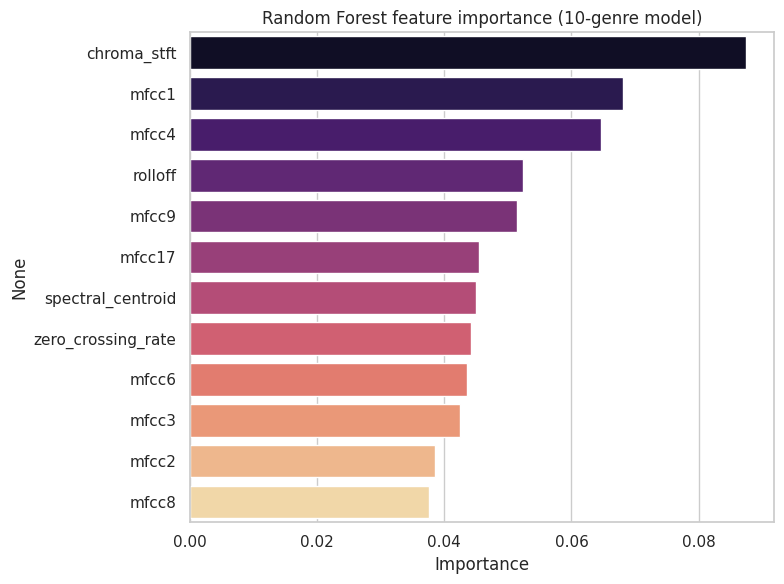

In [8]:
plt.figure(figsize=(8, 6))
top12 = importances.head(12)
sns.barplot(x=top12.values, y=top12.index, palette="magma")
plt.title("Random Forest feature importance (10-genre model)")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()

MFCCs dominate here too (77% of importance, vs. Yadav's 42.6%) — expected,
since this reproduction used all 20 MFCC coefficients where Yadav used 13
and also included `spectral_contrast`, which would have absorbed some of
that importance share in their model. The direction of the finding matches
across both independent runs: **timbral (MFCC) features are the primary
genre signal**, echoing the EDA's ANOVA result from Step 5.

## 6. Discussion & path forward for Step 7

**What reproducing these results actually showed:**

- A vanilla Random Forest on handcrafted features gets this capstone to
  roughly **66% at 10 genres** — in line with two independent published
  10-genre classical-ML baselines (61–65%), confirming this feature set and
  problem difficulty are "normal," not a data or pipeline bug.
- There is real headroom above classical ML: published results reach
  **75–90%** using either more genre-aware feature engineering (Yadav's
  78.2% RF with spectral contrast added) or a switch to CNNs on
  mel-spectrograms / transfer-learned audio embeddings (75–90%).
- MFCCs are consistently the dominant signal for genre in every source
  surveyed, which argues for keeping (or even expanding) MFCC-derived
  features rather than trimming them for simplicity.

**Proposed direction to discuss with mentor for Step 7:**

1. Use this notebook's Random Forest as the **baseline to beat**, since it's
   now grounded against real prior work rather than an arbitrary number.
2. Prioritize experimenting with **gradient-boosted trees (XGBoost/LightGBM)**
   over plain Random Forest, since chittalpatel's repo suggests boosting
   moves the needle within the classical-ML family; also try adding
   **spectral contrast** as a feature, since Yadav's higher classical-ML
   score used it and this dataset doesn't currently include it.
3. Treat a **CNN-on-spectrogram** approach as a stretch goal / comparison
   point for Step 7 rather than the primary plan, since it requires
   re-deriving spectrogram images from raw audio (a different pipeline than
   the feature-CSV this capstone currently has) for a further ~10-20 point
   accuracy gain based on the literature above.